In [3]:
import numpy as np                           
import pandas as pd                                 
import matplotlib.pyplot as plt 

from sklearn.pipeline import Pipeline           
from sklearn.compose import ColumnTransformer     
from sklearn.preprocessing import StandardScaler, RobustScaler      
from sklearn.preprocessing import OneHotEncoder       
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [4]:
data = pd.read_csv("..\\data\\data_more_features.csv")
data.head()

,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Model,Brand
0,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1627.325,WAGON R LXI CNG,MARUTI
1,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,11623.750,CRETA 1.6 CRDI SX OPTION,HYUNDAI
2,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4184.550,JAZZ V,HONDA
3,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,5579.400,ERTIGA VDI,MARUTI
4,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,16496.426,A4 NEW 2.0 TDI MULTITRONIC,AUDI


In [5]:
X = data.drop(columns=["Price"])
y = data["Price"] 

In [6]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[                       
    ("scaler", RobustScaler())                       
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),     
        ("cat", categorical_transformer, categorical_features)  
    ]
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y,                                             
    test_size=0.2,                                   
    random_state=42                                   
)

In [8]:
linreg_model1 = Pipeline(steps=[
    ("preprocess", preprocess),                        # Preprocess (fit on train only)
    ("model", LinearRegression())                      # Linear regression model
])

linreg_model1.fit(X_train, y_train)                     # Fit pipeline on training set only
print("Linear Regression trained.")

Linear Regression trained.


In [9]:
def evaluate_regression(model, X_test, y_test, name="model"):
    """
    Evaluate a regression model on the test set using:
    - MAE
    - RMSE
    - R²
    Also plots Actual vs Predicted.
    """
    preds = model.predict(X_test)                     

    mae = mean_absolute_error(y_test, preds)          
    rmse = np.sqrt(mean_squared_error(y_test, preds)) 
    r2 = r2_score(y_test, preds)                      

    print(f"\n--- {name} ---")                        
    print(f"MAE : {mae:.4f}")                         
    print(f"RMSE: {rmse:.4f}")                        
    print(f"R^2 : {r2:.4f}")                          

    plt.figure()                                      
    plt.scatter(y_test, preds, s=8)                   
    plt.title(f"{name}: Actual vs Predicted")         
    plt.xlabel("Actual")                              
    plt.ylabel("Predicted")                           
    plt.show()                                        

    return mae, rmse, r2 


--- Linear Regression ---
MAE : 3199.7592
RMSE: 6206.1533
R^2 : 0.6380


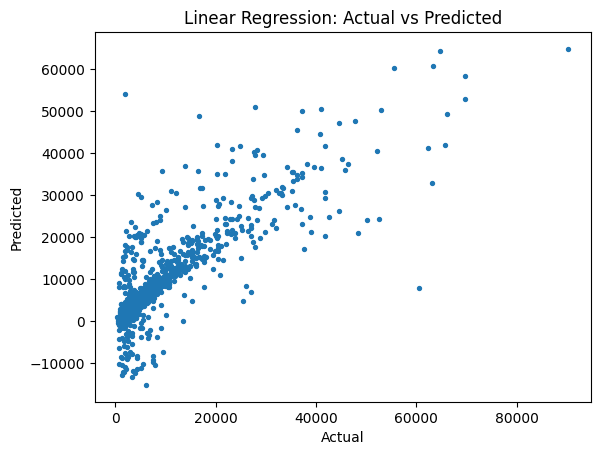

In [10]:
linreg_scores = evaluate_regression(                   # Evaluate baseline model
    linreg_model1,                                      # Pipeline
    X_test,                                            # Test features
    y_test,                                            # Test target
    "Linear Regression"                                # Name
)